 First 5 Records
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7229300521  20141013T000000  231300.0         2       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcod

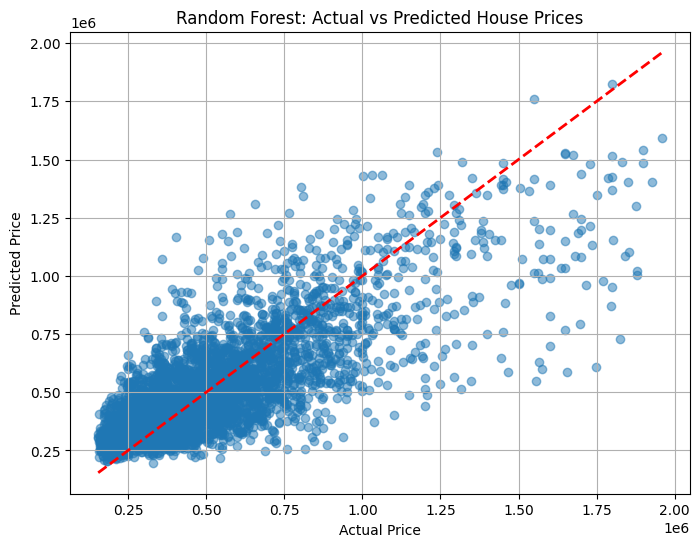


 Feature Importance
         Feature  Importance
7          grade    0.490717
0    sqft_living    0.194202
8     sqft_above    0.082105
9  sqft_basement    0.053026
2      bathrooms    0.047493
5           view    0.042364
6      condition    0.032170
3         floors    0.025809
1       bedrooms    0.025231
4     waterfront    0.006883


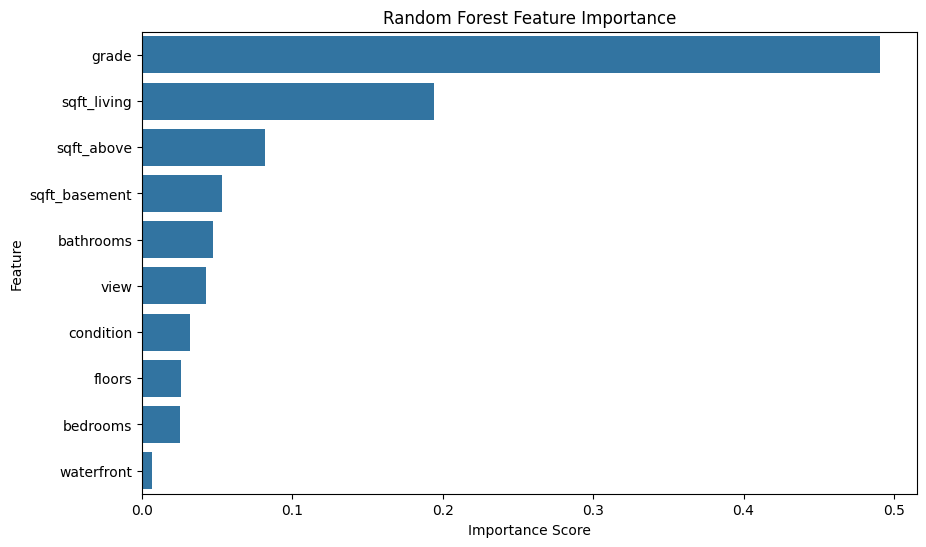

In [7]:
## House Price Prediction using Random Forest Regressor

# ==================================
# IMPORT LIBRARIES
# ==================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==================================
# LOAD DATASET
# ==================================

df = pd.read_csv('/content/Housing.csv')

print(' First 5 Records')
print(df.head())

print('\n Dataset Columns')
print(df.columns.tolist())

print('\n Missing Values')
print(df.isnull().sum())

# ==================================
# DATA CLEANING
# ==================================

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print('\n Dataset Shape :', df.shape)

# ==================================
# REMOVE EXTREME OUTLIERS (OPTIONAL)
# ==================================

q1 = df['price'].quantile(0.01)
q99 = df['price'].quantile(0.99)

df = df[
    (df['price'] >= q1) &
    (df['price'] <= q99)
]

print(' Shape after removing outliers :', df.shape)

# ==================================
# SELECT FEATURES
# ==================================

features = [
    'sqft_living',
    'bedrooms',
    'bathrooms',
    'floors',
    'waterfront',
    'view',
    'condition',
    'grade',
    'sqft_above',
    'sqft_basement',
]

X = df[features]
y = df['price']

# ==================================
# TRAIN / TEST SPLIT
# ==================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('\n Training Data Shape :', X_train.shape)
print(' Testing Data Shape  :', X_test.shape)

# ==================================
# RANDOM FOREST MODEL
# ==================================

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train model
model.fit(X_train, y_train)

print('\n Random Forest Model Trained Successfully')

# ==================================
# PREDICT TEST DATA
# ==================================

y_pred = model.predict(X_test)

# ==================================
# MODEL EVALUATION
# ==================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print('\n RANDOM FOREST VALIDATION REPORT')
print('=' * 50)

print(f'MAE  : ₹{mae:,.2f}')
print(f'MSE  : {mse:,.2f}')
print(f'RMSE : ₹{rmse:,.2f}')
print(f'R\u00b2   : {r2:.4f}')

print('=' * 50)

# ==================================
# ACTUAL vs PREDICTED COMPARISON
# ==================================

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred.round(2)
})

print('\n Sample Predictions')
print(comparison.head(10))

# ==================================
# USER INPUT FOR NEW PREDICTION
# ==================================

print('\n ENTER HOUSE DETAILS')

sqft_living = float(input('Living Area (sq ft): '))
bedrooms = int(input('Bedrooms: '))
bathrooms = float(input('Bathrooms: '))
floors = float(input('Floors: '))
waterfront = int(input('Waterfront (0 = No, 1 = Yes): '))
view = int(input('View Rating (0-4): '))
condition = int(input('Condition Rating (1-5): '))
grade = int(input('Grade (1-13): '))
sqft_above = float(input('Sqft Above Ground: '))
sqft_basement = float(input('Sqft Basement: '))

# Create DataFrame for prediction

user = pd.DataFrame([[
    sqft_living,
    bedrooms,
    bathrooms,
    floors,
    waterfront,
    view,
    condition,
    grade,
    sqft_above,
    sqft_basement,
]], columns=features)

# ==================================
# PREDICT HOUSE PRICE
# ==================================

predicted_price = model.predict(user)

print('\n' + '=' * 50)
print(f' PREDICTED HOUSE PRICE : \u20b9{predicted_price[0]:,.2f}')
print('=' * 50)

# ==================================
# ACTUAL vs PREDICTED GRAPH
# ==================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted House Prices')

plt.grid(True)

plt.show()

# ==================================
# FEATURE IMPORTANCE
# ==================================

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print('\n Feature Importance')
print(importance)

# Plot feature importance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')

plt.xlabel('Importance Score')

plt.ylabel('Feature')

plt.show()

In [8]:
# ==================================
# CHECK R² SCORE FOR RANDOM FOREST
# ==================================

from sklearn.metrics import r2_score

# Predict on test data
y_pred = model.predict(X_test)

# Calculate R² score
r2 = r2_score(y_test, y_pred)

# Display result
print("\\n Random Forest R² Score")
print("-" * 35)
print(f"R² Score : {r2:.4f}")

# Interpretation
print(f"Model explains {r2 * 100:.2f}% of the price variation.")

\n Random Forest R² Score
-----------------------------------
R² Score : 0.5900
Model explains 59.00% of the price variation.
